#Library

In [ ]:
from google.colab import drive
# General
import os
import re
import itertools
import warnings
import tempfile
# Data manipulation
import pandas as pd
import numpy as np
# Visualization
import matplotlib.pyplot as plt
from wordcloud import WordCloud
# PyTorch & Transformers
import torch
from transformers import AutoTokenizer, AutoModel
# Scikit-learn
from sklearn.model_selection import (train_test_split,StratifiedKFold)
from sklearn.preprocessing import (LabelEncoder,normalize)
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.metrics import (
    silhouette_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    balanced_accuracy_score,
    confusion_matrix,
    classification_report)
# TensorFlow / Keras
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Input,
    Masking,
    Bidirectional,
    LSTM,
    Dense,
    Dropout)
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau)
from tensorflow.keras.regularizers import l2
from tensorflow.keras.utils import to_categorical
# Ignore warnings
warnings.filterwarnings('ignore')

In [ ]:
import os
import random
import numpy as np
import tensorflow as tf
import torch

SEED = 42

os.environ['PYTHONHASHSEED'] = str(SEED)

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
torch.manual_seed(SEED)

# jika pakai GPU
torch.cuda.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# agar hasil lebih reproducible
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [ ]:
import torch

print("CUDA available :", torch.cuda.is_available())
print("CUDA version   :", torch.version.cuda)
print("GPU count      :", torch.cuda.device_count())

if torch.cuda.is_available():
    print("GPU name       :", torch.cuda.get_device_name(0))

CUDA available : False
CUDA version   : None
GPU count      : 0


#TIME & RAM

In [ ]:
# ============================================================
# TIMER & RAM MONITORING
# ============================================================

import time
import psutil
import pandas as pd

# ============================================================
# TEMPAT PENYIMPANAN
# ============================================================

time_records = []

# ============================================================
# FUNGSI CEK RAM
# ============================================================

def get_ram_usage():

    ram = psutil.virtual_memory()

    used_ram_gb = (
        ram.used / (1024**3)
    )

    return round(
        used_ram_gb,
        4
    )

# ============================================================
# FUNGSI SIMPAN MONITORING
# ============================================================

def simpan_monitoring(

    metode,
    tahap,
    parameter,
    waktu,
    ram_before,
    ram_after
):

    time_records.append({

        "Metode": metode,

        "Tahap": tahap,

        "Parameter": parameter,

        "Waktu (detik)": round(
            waktu,
            4
        ),

        "RAM Sebelum (GB)": round(
            ram_before,
            4
        ),

        "RAM Sesudah (GB)": round(
            ram_after,
            4
        ),

        "Kenaikan RAM (GB)": round(
            ram_after - ram_before,
            4
        )
    })

#Input Data

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
drive.mount('/content/drive')
df = pd.read_excel(
    '/content/drive/MyDrive/Thesis/data/hasil_normalisasi.xlsx',
    sheet_name='All',
    engine='openpyxl'
)
df_clean = df[['text_clean1', 'Labelling_clean']]
df_clean

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,text_clean1,Labelling_clean
0,memang mandiri menguras uang sekali omong-omon...,negatif
1,utbk tinggal beberapa bulan lagi,netral
2,cari beasiswa saudara kalau kipk sistemnya har...,positif
3,saat belajar utbk sampai meninggal,negatif
4,teman-teman anak fib sastra bahasa ada ikut u...,netral
...,...,...
1193,walaupun capek tapi seru juga punya teman sepe...,positif
1194,semangat terus buat yang lagi persiapan utbk k...,positif
1195,senang karena akhirnya berani daftar jurusan y...,positif
1196,semoga semua doa baik tentang ptn impian bisa ...,positif


#Exploration

###Karakteristik

In [ ]:
# Documents
documents = df_clean['text_clean1'].apply(
    lambda x: ' '.join(x) if isinstance(x, list) else x
).tolist()

# Labels
le = LabelEncoder()
y_encoded = le.fit_transform(df['Labelling_clean'])
num_classes = len(le.classes_)

# Sequence length
seq_length = 1

# 🔹 Total jumlah kata
total_words = sum(len(doc.split()) for doc in documents)

# 🔹 Jumlah kata unik (vocabulary size)
unique_words = len(set(word for doc in documents for word in doc.split()))

print(f"Documents: {len(documents)}")
print(f"Num classes: {num_classes}")
print(f"Seq length: {seq_length}")
print(f"Total words: {total_words}")
print(f"Unique words: {unique_words}")

Documents: 1198
Num classes: 3
Seq length: 1
Total words: 18108
Unique words: 2831


###perbandingan jumlah kelas

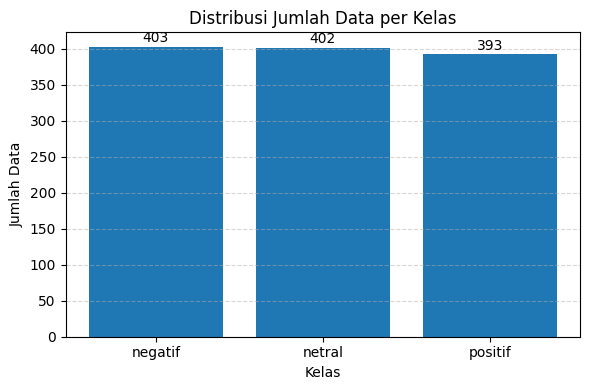

In [ ]:
label_counts = df['Labelling_clean'].value_counts()

plt.figure(figsize=(6,4))

bars = plt.bar(
    label_counts.index,
    label_counts.values
)

plt.title('Distribusi Jumlah Data per Kelas')
plt.xlabel('Kelas')
plt.ylabel('Jumlah Data')

# tampilkan angka di atas bar
for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 2,
        str(bar.get_height()),
        ha='center',
        va='bottom'
    )

plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

#Split Data

In [ ]:
X_train_text, X_test_text, y_train, y_test = train_test_split(
    documents,
    y_encoded,
    test_size=0.2,
    stratify=y_encoded,
    random_state=42)

tfidf_results = {}

         Train  Test
negatif    322    81
netral     322    80
positif    314    79


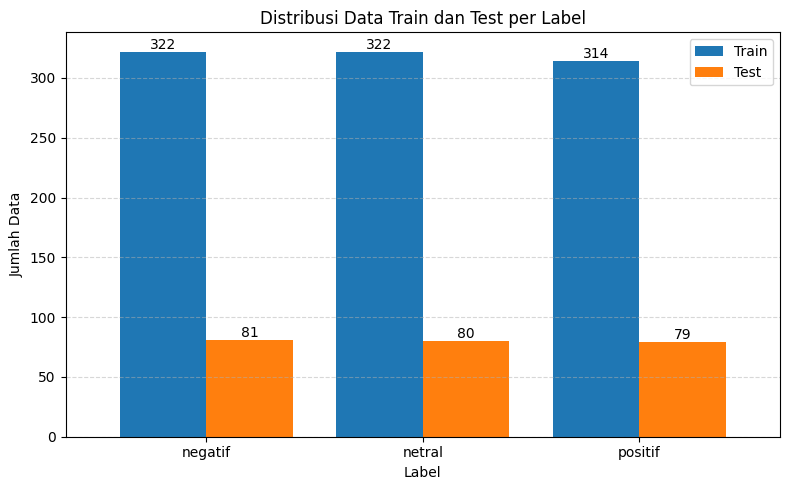

In [ ]:
# ubah kembali label numerik ke nama kelas
train_labels = le.inverse_transform(y_train)
test_labels  = le.inverse_transform(y_test)

# hitung jumlah tiap kelas
train_counts = pd.Series(train_labels).value_counts().sort_index()
test_counts  = pd.Series(test_labels).value_counts().sort_index()

# dataframe untuk plotting
df_split = pd.DataFrame({
    'Train': train_counts,
    'Test': test_counts})
print(df_split)
ax = df_split.plot(
    kind='bar',
    figsize=(8,5),
    width=0.8)

plt.title('Distribusi Data Train dan Test per Label')
plt.xlabel('Label')
plt.ylabel('Jumlah Data')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.5)

# tampilkan angka di atas bar
for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.show()

#Train


## TF-IDF Train

###Kombinasi Parameter TF-IDF


In [ ]:
min_df_options = [2, 3]
max_df_options = [0.8, 0.9]
max_feat_options = [1500,2500]

combinations = list(itertools.product(
    min_df_options,
    max_df_options,
    max_feat_options))

print("Jumlah kombinasi:", len(combinations))

Jumlah kombinasi: 8


### 1: RAM & Time Ekstraksi

###Ekstraksi Fitur

In [ ]:
# ============================================================
# TF-IDF FEATURE EXTRACTION + MONITORING
# ============================================================

tfidf_results = {}

for min_df, max_df, max_feat in combinations:

    parameter_info = (

        f"min_df={min_df}, "

        f"max_df={max_df}, "

        f"max_features={max_feat}"
    )

    print(f"\n===== {parameter_info} =====")

    # ========================================================
    # TIMER START
    # ========================================================

    ram_before = get_ram_usage()

    start_time = time.time()

    # ========================================================
    # TF-IDF
    # ========================================================

    vectorizer = TfidfVectorizer(

        min_df=min_df,

        max_df=max_df,

        max_features=max_feat,

        ngram_range=(1,1),

        use_idf=True,

        smooth_idf=True,

        sublinear_tf=True,

        norm='l2'
    )

    # ========================================================
    # FIT TRAIN
    # ========================================================

    X_train_tfidf = vectorizer.fit_transform(
        X_train_text
    )

    # ========================================================
    # SORT FEATURE
    # ========================================================

    scores = np.asarray(
        X_train_tfidf.sum(axis=0)
    ).flatten()

    sorted_idx = np.argsort(scores)[::-1]

    X_train_sorted = X_train_tfidf[:, sorted_idx]

    # ========================================================
    # SIMPAN FITUR
    # ========================================================

    features = vectorizer.get_feature_names_out()

    features_sorted = features[sorted_idx]

    # ========================================================
    # TIMER END
    # ========================================================

    end_time = time.time()

    ram_after = get_ram_usage()

    elapsed_time = (
        end_time - start_time
    )

    # ========================================================
    # SIMPAN MONITORING
    # ========================================================

    simpan_monitoring(

        metode="TF-IDF",

        tahap="Feature Extraction",

        parameter=parameter_info,

        waktu=elapsed_time,

        ram_before=ram_before,

        ram_after=ram_after
    )

    # ========================================================
    # SIMPAN
    # ========================================================

    key = f"min{min_df}_max{max_df}_feat{max_feat}"

    tfidf_results[key] = {

        "X_train": X_train_sorted,

        "y_train": y_train,

        "vectorizer": vectorizer,

        "sorted_idx": sorted_idx,

        "features": features_sorted
    }

    # ========================================================
    # OUTPUT
    # ========================================================

    print(
        "Shape :",
        X_train_sorted.shape
    )

    print(
        f"Waktu : "
        f"{elapsed_time:.2f} detik"
    )

    print(
        f"RAM : "
        f"{ram_before:.2f} GB -> "
        f"{ram_after:.2f} GB"
    )


===== min_df=2, max_df=0.8, max_features=1500 =====
Shape : (958, 1136)
Waktu : 0.04 detik
RAM : 2.77 GB -> 2.77 GB

===== min_df=2, max_df=0.8, max_features=2500 =====
Shape : (958, 1136)
Waktu : 0.02 detik
RAM : 2.77 GB -> 2.77 GB

===== min_df=2, max_df=0.9, max_features=1500 =====
Shape : (958, 1136)
Waktu : 0.02 detik
RAM : 2.77 GB -> 2.77 GB

===== min_df=2, max_df=0.9, max_features=2500 =====
Shape : (958, 1136)
Waktu : 0.02 detik
RAM : 2.77 GB -> 2.77 GB

===== min_df=3, max_df=0.8, max_features=1500 =====
Shape : (958, 769)
Waktu : 0.02 detik
RAM : 2.77 GB -> 2.77 GB

===== min_df=3, max_df=0.8, max_features=2500 =====
Shape : (958, 769)
Waktu : 0.02 detik
RAM : 2.77 GB -> 2.77 GB

===== min_df=3, max_df=0.9, max_features=1500 =====
Shape : (958, 769)
Waktu : 0.02 detik
RAM : 2.77 GB -> 2.77 GB

===== min_df=3, max_df=0.9, max_features=2500 =====
Shape : (958, 769)
Waktu : 0.02 detik
RAM : 2.77 GB -> 2.77 GB


##BiLSTM Train

###Kombinasi Parameter BiLSTM

In [ ]:
epochs_list = [10, 20]
batch_size_list = [64]
results = []

###cross validation

In [ ]:
skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42)

###Persiapan Data Train

In [ ]:
def prepare_bilstm_input(X_sparse, seq_length):

    # sparse -> dense
    X = X_sparse.toarray()
    n_samples, n_features = X.shape

    # PADDING
    remainder = n_features % seq_length
    if remainder != 0:
        pad_len = seq_length - remainder
        X = np.pad(
            X,
            ((0,0),(0,pad_len)),
            mode='constant')

    # RESHAPE
    X = X.reshape(
        X.shape[0],
        seq_length,
        X.shape[1] // seq_length)

    return X

###Arsitektur BiLSTM

In [ ]:
def build_bilstm_model(input_shape):

    model = Sequential([
        Input(shape=input_shape),
        Bidirectional(
            LSTM(64,
                dropout=0.5,
                recurrent_dropout=0.5,
                kernel_regularizer=l2(1e-4)) ),
        Dense(64,
            activation='relu',
            kernel_regularizer=l2(1e-4)),

        Dropout(0.5),
        Dense(3, activation='softmax')])

    model.compile(
        loss='sparse_categorical_crossentropy',
        optimizer='adam',
        metrics=['accuracy'])

    return model

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2,
    min_lr=1e-5)

###Tunning Hiperparameter

###Fungsi Training

In [ ]:
def train_and_evaluate_model(X, y, epochs, batch_size):

    fold_losses = []
    fold_accuracies = []

    for train_idx, val_idx in skf.split(X, y):

        X_fold_train = X[train_idx]
        X_fold_val = X[val_idx]

        y_fold_train = y[train_idx]
        y_fold_val = y[val_idx]

        tf.keras.backend.clear_session()

        model = build_bilstm_model(
            input_shape=(
                X_fold_train.shape[1],
                X_fold_train.shape[2]))

        model.fit(
            X_fold_train,
            y_fold_train,
            epochs=epochs,
            batch_size=batch_size,
            verbose=0,
            validation_data=(X_fold_val, y_fold_val),
            callbacks=[early_stop, reduce_lr])

        loss, acc = model.evaluate(
            X_fold_val,
            y_fold_val,
            verbose=0)

        fold_losses.append(loss)
        fold_accuracies.append(acc)

    return np.mean(fold_losses), np.mean(fold_accuracies)

### 2: RAM & Time Tunning ⏲

###Tunning Hiperparameter

In [ ]:
# ============================================================
# TUNING BiLSTM + MONITORING + DETAIL FOLD
# ============================================================

results = []

all_fold_scores = []

for key, data in tfidf_results.items():

    print(f"\n===== {key} =====")

    X_train_full = data["X_train"]

    y_train_full = data["y_train"]

    X = prepare_bilstm_input(

        X_train_full,

        seq_length
    )

    # ========================================================
    # LOOP EPOCH
    # ========================================================

    for epochs in epochs_list:

        # ====================================================
        # LOOP BATCH SIZE
        # ====================================================

        for batch_size in batch_size_list:

            parameter_info = (

                f"{key} | "

                f"ep={epochs} | "

                f"bs={batch_size}"
            )

            # =================================================
            # RAM SEBELUM TRAINING
            # =================================================

            ram_before = get_ram_usage()

            # =================================================
            # TIMER MULAI
            # =================================================

            start_time = time.perf_counter()

            fold_accs = []

            # =================================================
            # CROSS VALIDATION
            # =================================================

            for fold, (

                train_idx,
                val_idx

            ) in enumerate(

                skf.split(X, y_train_full),
                start=1
            ):

                # =============================================
                # CLEAR SESSION
                # =============================================

                tf.keras.backend.clear_session()

                # =============================================
                # SPLIT DATA
                # =============================================

                X_train_fold = X[train_idx]

                X_val_fold = X[val_idx]

                y_train_fold = y_train_full[train_idx]

                y_val_fold = y_train_full[val_idx]

                # =============================================
                # BUILD MODEL
                # =============================================

                model = build_bilstm_model(

                    input_shape=(

                        X_train_fold.shape[1],

                        X_train_fold.shape[2]
                    )
                )

                # =============================================
                # TRAINING
                # =============================================

                model.fit(

                    X_train_fold,

                    y_train_fold,

                    validation_data=(

                        X_val_fold,

                        y_val_fold
                    ),

                    epochs=epochs,

                    batch_size=batch_size,

                    callbacks=[

                        early_stop,

                        reduce_lr
                    ],

                    verbose=0
                )

                # =============================================
                # EVALUASI
                # =============================================

                _, acc = model.evaluate(

                    X_val_fold,

                    y_val_fold,

                    verbose=0
                )

                fold_accs.append(acc)

                # =============================================
                # PRINT PER FOLD
                # =============================================

                print(
                    f"Fold {fold} Accuracy : "
                    f"{acc:.4f}"
                )

            # =================================================
            # TIMER SELESAI
            # =================================================

            end_time = time.perf_counter()

            elapsed_time = (
                end_time - start_time
            )

            # =================================================
            # RAM SESUDAH TRAINING
            # =================================================

            ram_after = get_ram_usage()

            ram_used = (
                ram_after - ram_before
            )

            # =================================================
            # METRIK
            # =================================================

            mean_acc = np.mean(fold_accs)

            std_acc = np.std(fold_accs)

            # =================================================
            # PRINT HASIL
            # =================================================

            print(
                f"\nep={epochs} | "
                f"bs={batch_size} | "
                f"acc={mean_acc:.4f} ± {std_acc:.4f}"
            )

            print(
                f"Waktu : "
                f"{elapsed_time:.2f} detik"
            )

            print(
                f"RAM : "
                f"{ram_before:.2f} GB -> "
                f"{ram_after:.2f} GB"
            )

            print(
                f"Kenaikan RAM : "
                f"{ram_used:.2f} GB"
            )

            # =================================================
            # SIMPAN MONITORING
            # =================================================

            simpan_monitoring(

                metode="TF-IDF + BiLSTM",

                tahap="Hyperparameter Tuning",

                parameter=parameter_info,

                waktu=elapsed_time,

                ram_before=ram_before,

                ram_after=ram_after
            )

            # =================================================
            # SIMPAN HASIL
            # =================================================

            result_dict = {

                "model": key,

                "epochs": epochs,

                "batch_size": batch_size,

                "mean_accuracy": mean_acc,

                "std": std_acc,

                "waktu_training": elapsed_time,

                "ram_before": ram_before,

                "ram_after": ram_after,

                "ram_used": ram_used
            }

            # =================================================
            # SIMPAN AKURASI TIAP FOLD
            # =================================================

            for i, fold_acc in enumerate(
                fold_accs,
                start=1
            ):

                result_dict[f"fold_{i}"] = fold_acc

            results.append(result_dict)

            all_fold_scores.append(result_dict)


===== min2_max0.8_feat1500 =====
Fold 1 Accuracy : 0.7396
Fold 2 Accuracy : 0.4948
Fold 3 Accuracy : 0.5104
Fold 4 Accuracy : 0.4607
Fold 5 Accuracy : 0.4712

ep=10 | bs=64 | acc=0.5353 ± 0.1036
Waktu : 54.73 detik
RAM : 2.77 GB -> 3.19 GB
Kenaikan RAM : 0.42 GB
Fold 1 Accuracy : 0.5000
Fold 2 Accuracy : 0.5156
Fold 3 Accuracy : 0.4948
Fold 4 Accuracy : 0.5654
Fold 5 Accuracy : 0.5236

ep=20 | bs=64 | acc=0.5199 ± 0.0250
Waktu : 59.03 detik
RAM : 3.19 GB -> 3.36 GB
Kenaikan RAM : 0.17 GB

===== min2_max0.8_feat2500 =====
Fold 1 Accuracy : 0.5000
Fold 2 Accuracy : 0.4948
Fold 3 Accuracy : 0.5417
Fold 4 Accuracy : 0.5079
Fold 5 Accuracy : 0.3927

ep=10 | bs=64 | acc=0.4874 ± 0.0501
Waktu : 51.49 detik
RAM : 3.36 GB -> 3.63 GB
Kenaikan RAM : 0.27 GB
Fold 1 Accuracy : 0.5260
Fold 2 Accuracy : 0.5000
Fold 3 Accuracy : 0.5677
Fold 4 Accuracy : 0.5183
Fold 5 Accuracy : 0.4346

ep=20 | bs=64 | acc=0.5093 ± 0.0435
Waktu : 52.13 detik
RAM : 3.63 GB -> 3.88 GB
Kenaikan RAM : 0.25 GB

===== min2_

###Parameter Terbaik

In [ ]:
df_results = pd.DataFrame(results)

df_results = df_results.sort_values(
    by="mean_accuracy",
    ascending=False
)

print("\n===== TOP RESULTS =====")

display(df_results.head())

# ============================================================
# MODEL TERBAIK
# ============================================================

best_model = df_results.iloc[0]

print("\n===== BEST MODEL =====")

print(best_model)

best_key = best_model["model"]

best_epochs = int(
    best_model["epochs"]
)

best_batch = int(
    best_model["batch_size"]
)

best_acc = best_model["mean_accuracy"]

best_std = best_model["std"]

# ============================================================
# CETAK PARAMETER TERBAIK
# ============================================================

print("\n===== PARAMETER TERBAIK =====")

print("Model       :", best_key)

print("Epochs      :", best_epochs)

print("Batch Size  :", best_batch)

print(
    f"Accuracy    : "
    f"{best_acc:.4f} ± {best_std:.4f}"
)


===== TOP RESULTS =====


,model,epochs,batch_size,mean_accuracy,std,waktu_training,ram_before,ram_after,ram_used,fold_1,fold_2,fold_3,fold_4,fold_5
0,min2_max0.8_feat1500,10,64,0.535346,0.103596,54.730857,2.7674,3.1876,0.4202,0.739583,0.494792,0.510417,0.460733,0.471204
13,min3_max0.9_feat1500,20,64,0.526167,0.046191,58.782227,6.0988,6.3139,0.2151,0.463542,0.567708,0.479167,0.575916,0.544503
1,min2_max0.8_feat1500,20,64,0.519884,0.025030,59.029703,3.1876,3.3554,0.1678,0.500000,0.515625,0.494792,0.565445,0.523560
8,min3_max0.8_feat1500,10,64,0.518794,0.040116,54.751456,4.9197,5.1621,0.2424,0.562500,0.458333,0.531250,0.486911,0.554974
3,min2_max0.8_feat2500,20,64,0.509326,0.043466,52.131467,3.6282,3.8766,0.2484,0.526042,0.500000,0.567708,0.518325,0.434555



===== BEST MODEL =====
model             min2_max0.8_feat1500
epochs                              10
batch_size                          64
mean_accuracy                 0.535346
std                           0.103596
waktu_training               54.730857
ram_before                      2.7674
ram_after                       3.1876
ram_used                        0.4202
fold_1                        0.739583
fold_2                        0.494792
fold_3                        0.510417
fold_4                        0.460733
fold_5                        0.471204
Name: 0, dtype: object

===== PARAMETER TERBAIK =====
Model       : min2_max0.8_feat1500
Epochs      : 10
Batch Size  : 64
Accuracy    : 0.5353 ± 0.1036


###Model TF-IDF terbaik

In [ ]:
tfidf_data = tfidf_results[best_key]
vectorizer = tfidf_data["vectorizer"]
sorted_idx = tfidf_data["sorted_idx"]

print("Best Key :", best_key)

print("min_df :", vectorizer.min_df)
print("max_df :", vectorizer.max_df)
print("max_features :", vectorizer.max_features)
print("ngram_range :", vectorizer.ngram_range)
print("use_idf :", vectorizer.use_idf)
print("smooth_idf :", vectorizer.smooth_idf)
print("sublinear_tf :", vectorizer.sublinear_tf)
print("norm :", vectorizer.norm)

print("Jumlah fitur :", len(vectorizer.get_feature_names_out()))
print("Ukuran sorted_idx :", len(sorted_idx))

Best Key : min2_max0.8_feat1500
min_df : 2
max_df : 0.8
max_features : 1500
ngram_range : (1, 1)
use_idf : True
smooth_idf : True
sublinear_tf : True
norm : l2
Jumlah fitur : 1136
Ukuran sorted_idx : 1136


##Bangun Model

In [ ]:
X_train_final_tfidf = tfidf_data["X_train"]
X_train_final = prepare_bilstm_input(
    X_train_final_tfidf,
    seq_length)

In [ ]:
tf.keras.backend.clear_session()

final_model = build_bilstm_model(
    input_shape=(
        X_train_final.shape[1],
        X_train_final.shape[2]))

In [ ]:
# ============================================================
# FINAL TRAIN MONITORING
# ============================================================

ram_before = get_ram_usage()

start_time = time.time()

history = final_model.fit(

    X_train_final,

    y_train,

    epochs=best_epochs,

    batch_size=best_batch,

    validation_split=0.2,

    callbacks=[
        early_stop,
        reduce_lr
    ],

    verbose=1
)

end_time = time.time()

ram_after = get_ram_usage()

elapsed_time = (
    end_time - start_time
)

simpan_monitoring(

    metode="TF-IDF + BiLSTM",

    tahap="Final Training",

    parameter=best_key,

    waktu=elapsed_time,

    ram_before=ram_before,

    ram_after=ram_after
)

print(
    f"\nFinal Training Time : "
    f"{elapsed_time:.2f} detik"
)

print(
    f"RAM : "
    f"{ram_before:.2f} GB -> "
    f"{ram_after:.2f} GB"
)

Epoch 1/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 8s 107ms/step - accuracy: 0.3368 - loss: 1.1765 - val_accuracy: 0.4427 - val_loss: 1.1598 - learning_rate: 0.0010
Epoch 2/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.4765 - loss: 1.1432 - val_accuracy: 0.5000 - val_loss: 1.1336 - learning_rate: 0.0010
Epoch 3/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.5535 - loss: 1.1216 - val_accuracy: 0.5156 - val_loss: 1.1203 - learning_rate: 5.0000e-04

Final Training Time : 8.72 detik
RAM : 6.81 GB -> 6.86 GB


#TEST

###Persiapan data test

In [ ]:
def prepare_bilstm_input(X_sparse, seq_length):
    X = X_sparse.toarray()
    n_samples, n_features = X.shape
    remainder = n_features % seq_length

    if remainder != 0:
        pad_len = seq_length - remainder
        X = np.pad(
            X,
            ((0,0),(0,pad_len)),
            mode='constant')

    X = X.reshape(
        X.shape[0],
        seq_length,
        X.shape[1] // seq_length)

    return X

### 3: RAM & Time Ekstraksi Data Test ⏲

###Ekstraksi Fitur data test

In [ ]:
# ============================================================
# TEST FEATURE EXTRACTION + MONITORING
# ============================================================

ram_before = get_ram_usage()

start_time = time.time()

# ============================================================
# TF-IDF TRANSFORM TEST
# ============================================================

X_test_tfidf = vectorizer.transform(
    X_test_text
)

# ============================================================
# SORT FEATURE
# ============================================================

X_test_sorted = X_test_tfidf[
    :,
    sorted_idx
]

# ============================================================
# RESHAPE UNTUK BiLSTM
# ============================================================

X_test_final = prepare_bilstm_input(

    X_test_sorted,

    seq_length
)

# ============================================================
# TIMER END
# ============================================================

end_time = time.time()

ram_after = get_ram_usage()

elapsed_time = (
    end_time - start_time
)

# ============================================================
# SIMPAN MONITORING
# ============================================================

simpan_monitoring(

    metode="TF-IDF",

    tahap="Feature Extraction Test",

    parameter=best_key,

    waktu=elapsed_time,

    ram_before=ram_before,

    ram_after=ram_after
)

# ============================================================
# OUTPUT
# ============================================================

print(
    "Train Shape :",
    X_train_final.shape
)

print(
    "Test Shape :",
    X_test_final.shape
)

print(
    f"Waktu Ekstraksi Test : "
    f"{elapsed_time:.2f} detik"
)

print(
    f"RAM : "
    f"{ram_before:.2f} GB -> "
    f"{ram_after:.2f} GB"
)

Train Shape : (958, 1, 1136)
Test Shape : (240, 1, 1136)
Waktu Ekstraksi Test : 0.01 detik
RAM : 6.86 GB -> 6.86 GB


###4: RAM & Time Prediksi ⏲

### Prediksi

In [ ]:
# ============================================================
# PREDICTION TEST + MONITORING
# ============================================================

ram_before = get_ram_usage()

start_time = time.time()

# ============================================================
# PREDIKSI
# ============================================================

y_pred_prob = final_model.predict(

    X_test_final,

    verbose=0
)

y_pred = np.argmax(

    y_pred_prob,

    axis=1
)

# ============================================================
# TIMER END
# ============================================================

end_time = time.time()

ram_after = get_ram_usage()

elapsed_time = (
    end_time - start_time
)

# ============================================================
# SIMPAN MONITORING
# ============================================================

simpan_monitoring(

    metode="TF-IDF + BiLSTM",

    tahap="Prediction Test",

    parameter=best_key,

    waktu=elapsed_time,

    ram_before=ram_before,

    ram_after=ram_after
)

# ============================================================
# OUTPUT
# ============================================================

print(
    f"Waktu Prediksi : "
    f"{elapsed_time:.2f} detik"
)

print(
    f"RAM : "
    f"{ram_before:.2f} GB -> "
    f"{ram_after:.2f} GB"
)

# ============================================================
# TEST ACCURACY
# ============================================================

test_acc = np.mean(
    y_pred == y_test
)

print(
    f"Test Accuracy : "
    f"{test_acc:.4f}"
)

Waktu Prediksi : 1.54 detik
RAM : 6.86 GB -> 6.85 GB
Test Accuracy : 0.4667


# Evaluasi

In [ ]:
def get_metrics(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)

    sensitivitas = []
    spesifisitas = []

    for i in range(cm.shape[0]):
        TP = cm[i, i]
        FN = cm[i, :].sum() - TP
        FP = cm[:, i].sum() - TP
        TN = cm.sum() - TP - FN - FP

        sensitivitas.append(TP / (TP + FN) if (TP + FN) > 0 else 0)
        spesifisitas.append(TN / (TN + FP) if (TN + FP) > 0 else 0)

    return {
        'Accuracy'          : accuracy_score(y_true, y_pred),
        'F1 Score'          : f1_score(y_true, y_pred, average='macro'),
        'Balanced Accuracy' : balanced_accuracy_score(y_true, y_pred),
        'Sensitivitas'      : np.mean(sensitivitas),
        'Spesifisitas'      : np.mean(spesifisitas)
    }

In [ ]:
y_pred_train = np.argmax(
    final_model.predict(X_train_final, verbose=0),
    axis=1
)

y_pred_test = np.argmax(
    final_model.predict(X_test_final, verbose=0),
    axis=1
)

metrik_train = get_metrics(y_train, y_pred_train)
metrik_test  = get_metrics(y_test, y_pred_test)

labels = list(metrik_train.keys())

train_values = list(metrik_train.values())
test_values  = list(metrik_test.values())

## BarChart

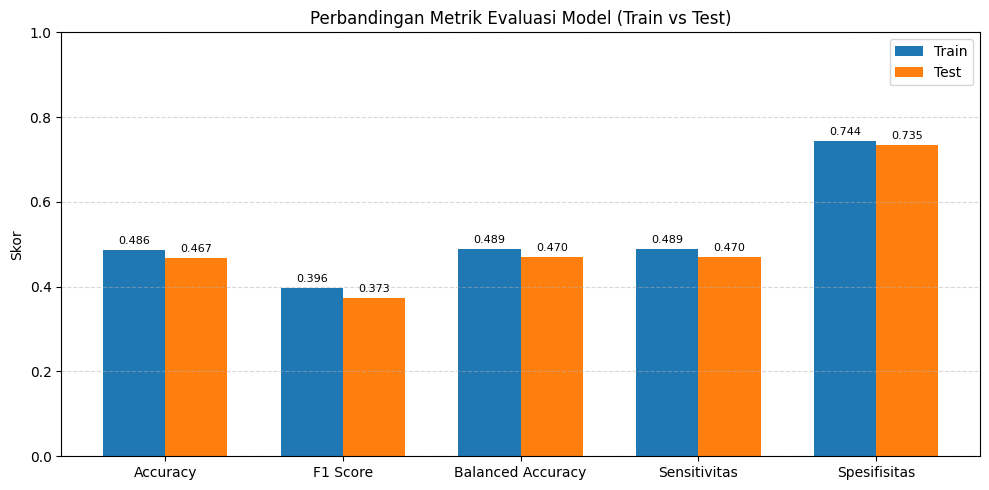

In [ ]:
# urutan metrik biar konsisten
labels = ['Accuracy', 'F1 Score', 'Balanced Accuracy', 'Sensitivitas', 'Spesifisitas']

train_values = [metrik_train[k] for k in labels]
test_values  = [metrik_test[k]  for k in labels]

x = np.arange(len(labels))
width = 0.35

plt.figure(figsize=(10,5))

bars1 = plt.bar(x - width/2, train_values, width, label='Train')
bars2 = plt.bar(x + width/2, test_values,  width, label='Test')

plt.xticks(x, labels)
plt.ylim(0, 1)
plt.title('Perbandingan Metrik Evaluasi Model (Train vs Test)')
plt.ylabel('Skor')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.5)

# label nilai di atas bar
for bars in [bars1, bars2]:
    for bar in bars:
        plt.text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.01,
            f'{bar.get_height():.3f}',
            ha='center', va='bottom', fontsize=8
        )

plt.tight_layout()
plt.show()

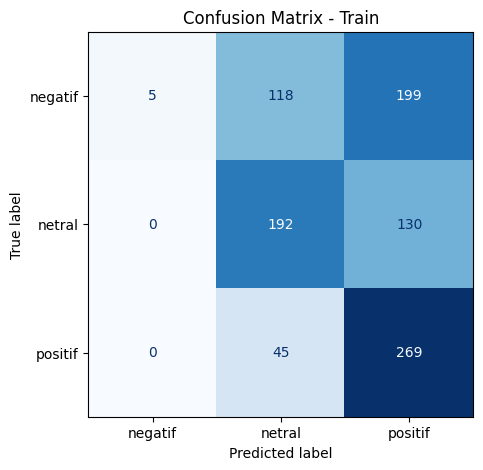

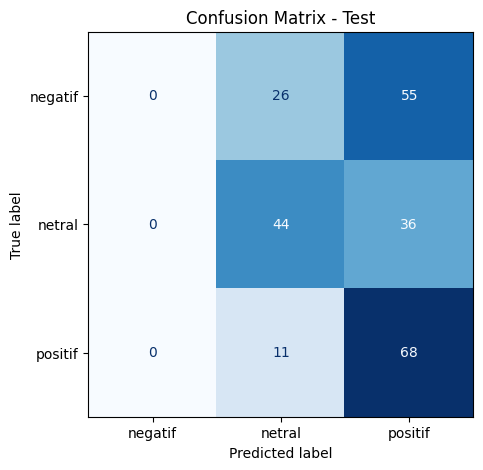

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# =========================
# CONFUSION MATRIX TRAIN
# =========================

cm_train = confusion_matrix(
    y_train,
    y_pred_train
)

disp_train = ConfusionMatrixDisplay(
    confusion_matrix=cm_train,
    display_labels=le.classes_
)

fig, ax = plt.subplots(figsize=(6,5))

disp_train.plot(
    cmap='Blues',
    ax=ax,
    colorbar=False
)

plt.title("Confusion Matrix - Train")
plt.grid(False)
plt.show()

# =========================
# CONFUSION MATRIX TEST
# =========================

cm_test = confusion_matrix(
    y_test,
    y_pred_test
)

disp_test = ConfusionMatrixDisplay(
    confusion_matrix=cm_test,
    display_labels=le.classes_
)

fig, ax = plt.subplots(figsize=(6,5))

disp_test.plot(
    cmap='Blues',
    ax=ax,
    colorbar=False
)

plt.title("Confusion Matrix - Test")
plt.grid(False)
plt.show()

#Rekap RAM & Timer

In [ ]:
# ============================================================
# REKAP MONITORING TF-IDF + BiLSTM
# ============================================================

from datetime import datetime
from google.colab import files

# ============================================================
# DATAFRAME MONITORING
# ============================================================

df_monitoring = pd.DataFrame(
    time_records
)

print("\n===== REKAP MONITORING =====")

display(df_monitoring)

# ============================================================
# TOTAL WAKTU
# ============================================================

total_waktu = df_monitoring[
    "Waktu (detik)"
].sum()

print(
    f"\nTotal Waktu Komputasi : "
    f"{total_waktu/60:.2f} menit"
)

# ============================================================
# TIMESTAMP
# ============================================================

timestamp = datetime.now().strftime(
    "%Y%m%d_%H%M%S"
)

# ============================================================
# IDENTITAS FILE
# ============================================================

file_identity = (

    f"TFIDF_BiLSTM_"

    f"min{vectorizer.min_df}_"

    f"max{vectorizer.max_df}_"

    f"feat{vectorizer.max_features}_"

    f"ep{best_epochs}_"

    f"bs{best_batch}_"

    f"{timestamp}"
)

# ============================================================
# OUTPUT DIRECTORY
# ============================================================

output_dir = (
    "/content/drive/MyDrive/Thesis/"
)

os.makedirs(
    output_dir,
    exist_ok=True
)

# ============================================================
# NAMA FILE
# ============================================================

output_filename = (

    f"monitoring_"

    f"{file_identity}.xlsx"
)

output_path = os.path.join(

    output_dir,

    output_filename
)

# ============================================================
# SAVE EXCEL
# ============================================================

df_monitoring.to_excel(

    output_path,

    index=False
)

# ============================================================
# OUTPUT
# ============================================================

print(
    f"\nMonitoring berhasil disimpan di:\n"
    f"{output_path}"
)

# ============================================================
# DOWNLOAD
# ============================================================

files.download(
    output_path
)


===== REKAP MONITORING =====


,Metode,Tahap,Parameter,Waktu (detik),RAM Sebelum (GB),RAM Sesudah (GB),Kenaikan RAM (GB)
0,TF-IDF,Feature Extraction,"min_df=2, max_df=0.8, max_features=1500",0.0395,2.7675,2.7659,-0.0016
1,TF-IDF,Feature Extraction,"min_df=2, max_df=0.8, max_features=2500",0.0191,2.7659,2.7659,0.0000
2,TF-IDF,Feature Extraction,"min_df=2, max_df=0.9, max_features=1500",0.0193,2.7659,2.7662,0.0003
3,TF-IDF,Feature Extraction,"min_df=2, max_df=0.9, max_features=2500",0.0180,2.7662,2.7664,0.0002
4,TF-IDF,Feature Extraction,"min_df=3, max_df=0.8, max_features=1500",0.0181,2.7664,2.7667,0.0003
5,TF-IDF,Feature Extraction,"min_df=3, max_df=0.8, max_features=2500",0.0188,2.7667,2.7669,0.0002
6,TF-IDF,Feature Extraction,"min_df=3, max_df=0.9, max_features=1500",0.0186,2.7669,2.7671,0.0002
7,TF-IDF,Feature Extraction,"min_df=3, max_df=0.9, max_features=2500",0.0179,2.7671,2.7674,0.0003
8,TF-IDF + BiLSTM,Hyperparameter Tuning,min2_max0.8_feat1500 | ep=10 | bs=64,54.7309,2.7674,3.1876,0.4202
9,TF-IDF + BiLSTM,Hyperparameter Tuning,min2_max0.8_feat1500 | ep=20 | bs=64,59.0297,3.1876,3.3554,0.1678



Total Waktu Komputasi : 15.17 menit

Monitoring berhasil disimpan di:
/content/drive/MyDrive/Thesis/monitoring_TFIDF_BiLSTM_min2_max0.8_feat1500_ep10_bs64_20260524_011850.xlsx


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# ============================================================
# EXPORT ARTIFACTS - TF-IDF + BiLSTM
# ============================================================

import os
import json
import joblib
import numpy as np
import pandas as pd
from google.colab import files
from datetime import datetime

# ============================================================
# TIMESTAMP
# ============================================================

timestamp = datetime.now().strftime(
    "%Y%m%d_%H%M%S"
)

# ============================================================
# RE-DEFINE VARIABLES
# ============================================================

class_names = list(le.classes_)

# ============================================================
# LABEL ASLI & HASIL PREDIKSI
# ============================================================

# Train predictions
y_pred_train = np.argmax(

    final_model.predict(

        X_train_final,

        verbose=0
    ),

    axis=1
)

# Test predictions
y_pred_test = np.argmax(

    final_model.predict(

        X_test_final,

        verbose=0
    ),

    axis=1
)

# ============================================================
# DECODE LABEL
# ============================================================

label_asli_train = le.inverse_transform(
    y_train
)

label_pred_train = le.inverse_transform(
    y_pred_train
)

label_asli_test = le.inverse_transform(
    y_test
)

label_pred_test = le.inverse_transform(
    y_pred_test
)

# ============================================================
# SOFTMAX PROBABILITIES
# ============================================================

y_prob_train = final_model.predict(

    X_train_final,

    verbose=0
)

y_prob_test = final_model.predict(

    X_test_final,

    verbose=0
)

conf_train = np.max(
    y_prob_train,
    axis=1
)

conf_test = np.max(
    y_prob_test,
    axis=1
)

# ============================================================
# DATAFRAME TRAIN
# ============================================================

df_train_result = pd.DataFrame({

    'teks'             : X_train_text,
    'data'             : 'train',
    'label_asli'       : label_asli_train,
    'label_prediksi'   : label_pred_train,
    'max_confidence'   : conf_train,
    'correct'          : (
        y_train == y_pred_train
    )
})

for idx, cls_name in enumerate(class_names):

    df_train_result[
        f'prob_{cls_name}'
    ] = y_prob_train[:, idx]

# ============================================================
# DATAFRAME TEST
# ============================================================

df_test_result = pd.DataFrame({

    'teks'             : X_test_text,
    'data'             : 'test',
    'label_asli'       : label_asli_test,
    'label_prediksi'   : label_pred_test,
    'max_confidence'   : conf_test,
    'correct'          : (
        y_test == y_pred_test
    )
})

for idx, cls_name in enumerate(class_names):

    df_test_result[
        f'prob_{cls_name}'
    ] = y_prob_test[:, idx]

# ============================================================
# GABUNG TRAIN + TEST
# ============================================================

df_hasil_klasifikasi = pd.concat(

    [df_train_result, df_test_result],

    ignore_index=True
)

display(
    df_hasil_klasifikasi.head()
)

# ============================================================
# IDENTITAS FILE
# ============================================================

file_identity = (

    f"TFIDF_BiLSTM_"

    f"min{vectorizer.min_df}_"

    f"max{vectorizer.max_df}_"

    f"feat{vectorizer.max_features}_"

    f"ep{best_epochs}_"

    f"bs{best_batch}_"

    f"{timestamp}"
)

# ============================================================
# SETUP OUTPUT DIRECTORY
# ============================================================

output_dir = (
    '/content/drive/MyDrive/Thesis/'
    'artifacts_tfidf_bilstm'
)

os.makedirs(

    output_dir,

    exist_ok=True
)

print(
    f"\nOutput directory : "
    f"{output_dir}"
)

print(
    f"Classes          : "
    f"{class_names}"
)

# ============================================================
# 1. SAVE PREDICTIONS + SOFTMAX
# ============================================================

predictions_filename = (

    f"predictions_softmax_"

    f"{file_identity}.xlsx"
)

predictions_path = os.path.join(

    output_dir,

    predictions_filename
)

df_hasil_klasifikasi.to_excel(

    predictions_path,

    index=False
)

print(
    f"\n✅ Predictions   : "
    f"{predictions_filename}"
)

# ============================================================
# 2. SAVE BiLSTM MODEL
# ============================================================

model_filename = (

    f"TFIDF_BiLSTM_model_"

    f"{file_identity}.keras"
)

model_path = os.path.join(

    output_dir,

    model_filename
)

final_model.save(
    model_path
)

print(
    f"✅ BiLSTM model  : "
    f"{model_filename}"
)

# ============================================================
# 3. SAVE TF-IDF VECTORIZER
# ============================================================

vectorizer_filename = (

    f"tfidf_vectorizer_"

    f"{file_identity}.pkl"
)

vectorizer_path = os.path.join(

    output_dir,

    vectorizer_filename
)

joblib.dump(

    vectorizer,

    vectorizer_path
)

print(
    f"✅ Vectorizer    : "
    f"{vectorizer_filename}"
)

# ============================================================
# 4. SAVE SORTED INDEX
# ============================================================

sorted_idx_filename = (

    f"sorted_idx_"

    f"{file_identity}.pkl"
)

sorted_idx_path = os.path.join(

    output_dir,

    sorted_idx_filename
)

joblib.dump(

    sorted_idx,

    sorted_idx_path
)

print(
    f"✅ Sorted Index  : "
    f"{sorted_idx_filename}"
)

# ============================================================
# 5. SAVE LABEL ENCODER
# ============================================================

le_filename = (

    f"label_encoder_"

    f"{file_identity}.pkl"
)

le_path = os.path.join(

    output_dir,

    le_filename
)

joblib.dump(
    le,
    le_path
)

print(
    f"✅ LabelEncoder  : "
    f"{le_filename}"
)

# ============================================================
# 6. SAVE METADATA
# ============================================================

metadata = {

    "model_type" : (
        "TF-IDF + BiLSTM"
    ),

    "tfidf_params" : {

        "min_df" : (
            vectorizer.min_df
        ),

        "max_df" : (
            vectorizer.max_df
        ),

        "max_features" : (
            vectorizer.max_features
        )
    },

    "best_params" : {

        "epochs" : int(
            best_epochs
        ),

        "batch_size" : int(
            best_batch
        )
    },

    "performance" : {

        "cv_mean_accuracy" : float(
            best_acc
        ),

        "cv_std" : float(
            best_std
        ),

        "test_accuracy" : float(
            test_acc
        )
    },

    "data_info" : {

        "num_train" : len(
            X_train_text
        ),

        "num_test" : len(
            X_test_text
        ),

        "num_classes" : len(
            class_names
        ),

        "class_names" : class_names
    }
}

metadata_filename = (

    f"metadata_"

    f"{file_identity}.json"
)

metadata_path = os.path.join(

    output_dir,

    metadata_filename
)

with open(
    metadata_path,
    'w'
) as f:

    json.dump(

        metadata,

        f,

        indent=2
    )

print(
    f"✅ Metadata      : "
    f"{metadata_filename}"
)

# ============================================================
# SUMMARY
# ============================================================

print("\n" + "="*60)

print(
    "EXPORT SUMMARY - TF-IDF + BiLSTM"
)

print("="*60)

for fname in sorted(
    os.listdir(output_dir)
):

    fpath = os.path.join(
        output_dir,
        fname
    )

    size_mb = (
        os.path.getsize(fpath)
        / (1024 * 1024)
    )

    print(
        f"  {fname:<65} "
        f"{size_mb:>8.2f} MB"
    )

print("="*60)

print(
    f"\n📂 Folder: "
    f"{output_dir}"
)

# ============================================================
# DOWNLOAD FILES
# ============================================================

print("\nMemulai download file...")

files.download(
    predictions_path
)

files.download(
    metadata_path
)

,teks,data,label_asli,label_prediksi,max_confidence,correct,prob_negatif,prob_netral,prob_positif
0,agak menyesal ikut tka harusnya saya fokus snb...,train,negatif,netral,0.340351,False,0.324888,0.340351,0.334760
1,lolos utbk tidak kak kalau iya universitas pr...,train,netral,netral,0.341356,True,0.322159,0.341356,0.336485
2,menuju lolos snbt,train,positif,positif,0.337756,True,0.325859,0.336386,0.337756
3,berita baik untuk kamu kawan pajak mau ikut s...,train,positif,netral,0.337678,False,0.325333,0.337678,0.336990
4,saya mau tanya lokasi ujian biasanya diumumkan...,train,netral,positif,0.337454,False,0.326429,0.336118,0.337454



Output directory : /content/drive/MyDrive/Thesis/artifacts_tfidf_bilstm
Classes          : ['negatif', 'netral', 'positif']

✅ Predictions   : predictions_softmax_TFIDF_BiLSTM_min2_max0.8_feat1500_ep10_bs64_20260524_011850.xlsx
✅ BiLSTM model  : TFIDF_BiLSTM_model_TFIDF_BiLSTM_min2_max0.8_feat1500_ep10_bs64_20260524_011850.keras
✅ Vectorizer    : tfidf_vectorizer_TFIDF_BiLSTM_min2_max0.8_feat1500_ep10_bs64_20260524_011850.pkl
✅ Sorted Index  : sorted_idx_TFIDF_BiLSTM_min2_max0.8_feat1500_ep10_bs64_20260524_011850.pkl
✅ LabelEncoder  : label_encoder_TFIDF_BiLSTM_min2_max0.8_feat1500_ep10_bs64_20260524_011850.pkl
✅ Metadata      : metadata_TFIDF_BiLSTM_min2_max0.8_feat1500_ep10_bs64_20260524_011850.json

EXPORT SUMMARY - TF-IDF + BiLSTM
  TFIDF_BiLSTM_model_TFIDF_BiLSTM_min2_max0.8_feat1500_ep10_bs64_20260524_011850.keras     7.17 MB
  TFIDF_BiLSTM_model_TFIDF_BiLSTM_min2_max0.9_feat2500_ep10_bs16_20260523_091854.keras     7.17 MB
  TFIDF_BiLSTM_model_TFIDF_BiLSTM_min2_max0.9_feat2500_e

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>